**Reduction de dimension**

In [1]:
import pandas as pd

In [2]:
insurance_claims = pd.read_csv('insurance_claims.csv', sep=',')
df = insurance_claims.copy()
# change col date to datetime
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

print(df.shape)

pd.set_option('display.max_columns', None)
df.head(5)

(1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


**I) Information mutuelle**  
L'information mutuelle ressemble beaucoup à la corrélation en ce sens qu'elle mesure une relation entre deux quantités. L'avantage de l'information mutuelle est qu'elle peut détecter tout type de relation, alors que la corrélation ne détecte que les relations linéaires.Elle calcule la réduction de l'entropie résultant de la transformation d'un ensemble de données et peut être utilisé pour la sélection des caractéristiques en évaluant le gain d'information de chaque variable dans le contexte de la variable cible.

In [21]:
#Préparation donnée
# Transformer la cible en 0 / 1
df['fraud_reported'] = (df['fraud_reported'].replace(['Y', 'N'], [1, 0])).astype(float)
df_num = df.drop(columns=['_c39']).select_dtypes(include='number')

df_num.columns
# Séparer X et y à partir de df_num
y = df_num['fraud_reported']
X = df_num.drop(columns=['fraud_reported'])

print(df_num.columns)


Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
       'auto_year', 'fraud_reported'],
      dtype='str')


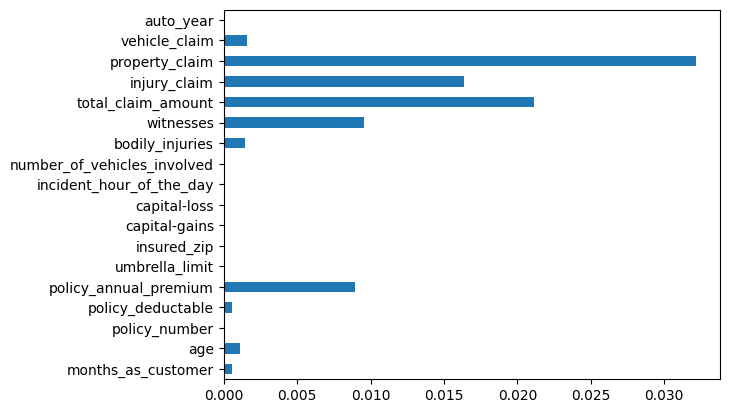

In [24]:
#!pip install scikit-learn
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
importances = mutual_info_classif(X, y)
feat_importances = pd.Series(importances, df_num.columns[0:len(df_num.columns)-1])
feat_importances.plot(kind = 'barh')
plt.show()




**Nous avons ainsi une représentation graphique des variables ayant apporté le plus d'information:**  
- proprety_claim  
- total_claim_amount  
- injury_claim  
- witnesses  
- policy annual premium  
- bodily injuries
- vehicle_claim
- age






**II) Forward Sequential Selection**  
La Forward Sequential Selection est une méthode itérative qui commence avec un modèle vide et ajoute itérativement des features en fonction de leur impact positif sur la performance du modèle, jusqu'à ce qu'un critère d'arrêt soit atteint.

In [35]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn, n_features_to_select=5)
sfs.fit(X, y)
sfs.get_feature_names_out()

array(['policy_annual_premium', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries',
       'total_claim_amount'], dtype=object)

**III) Test si il y a une différence significative entre fraude et non Fraude**

1) test si l'échantillon suit la distribution normale

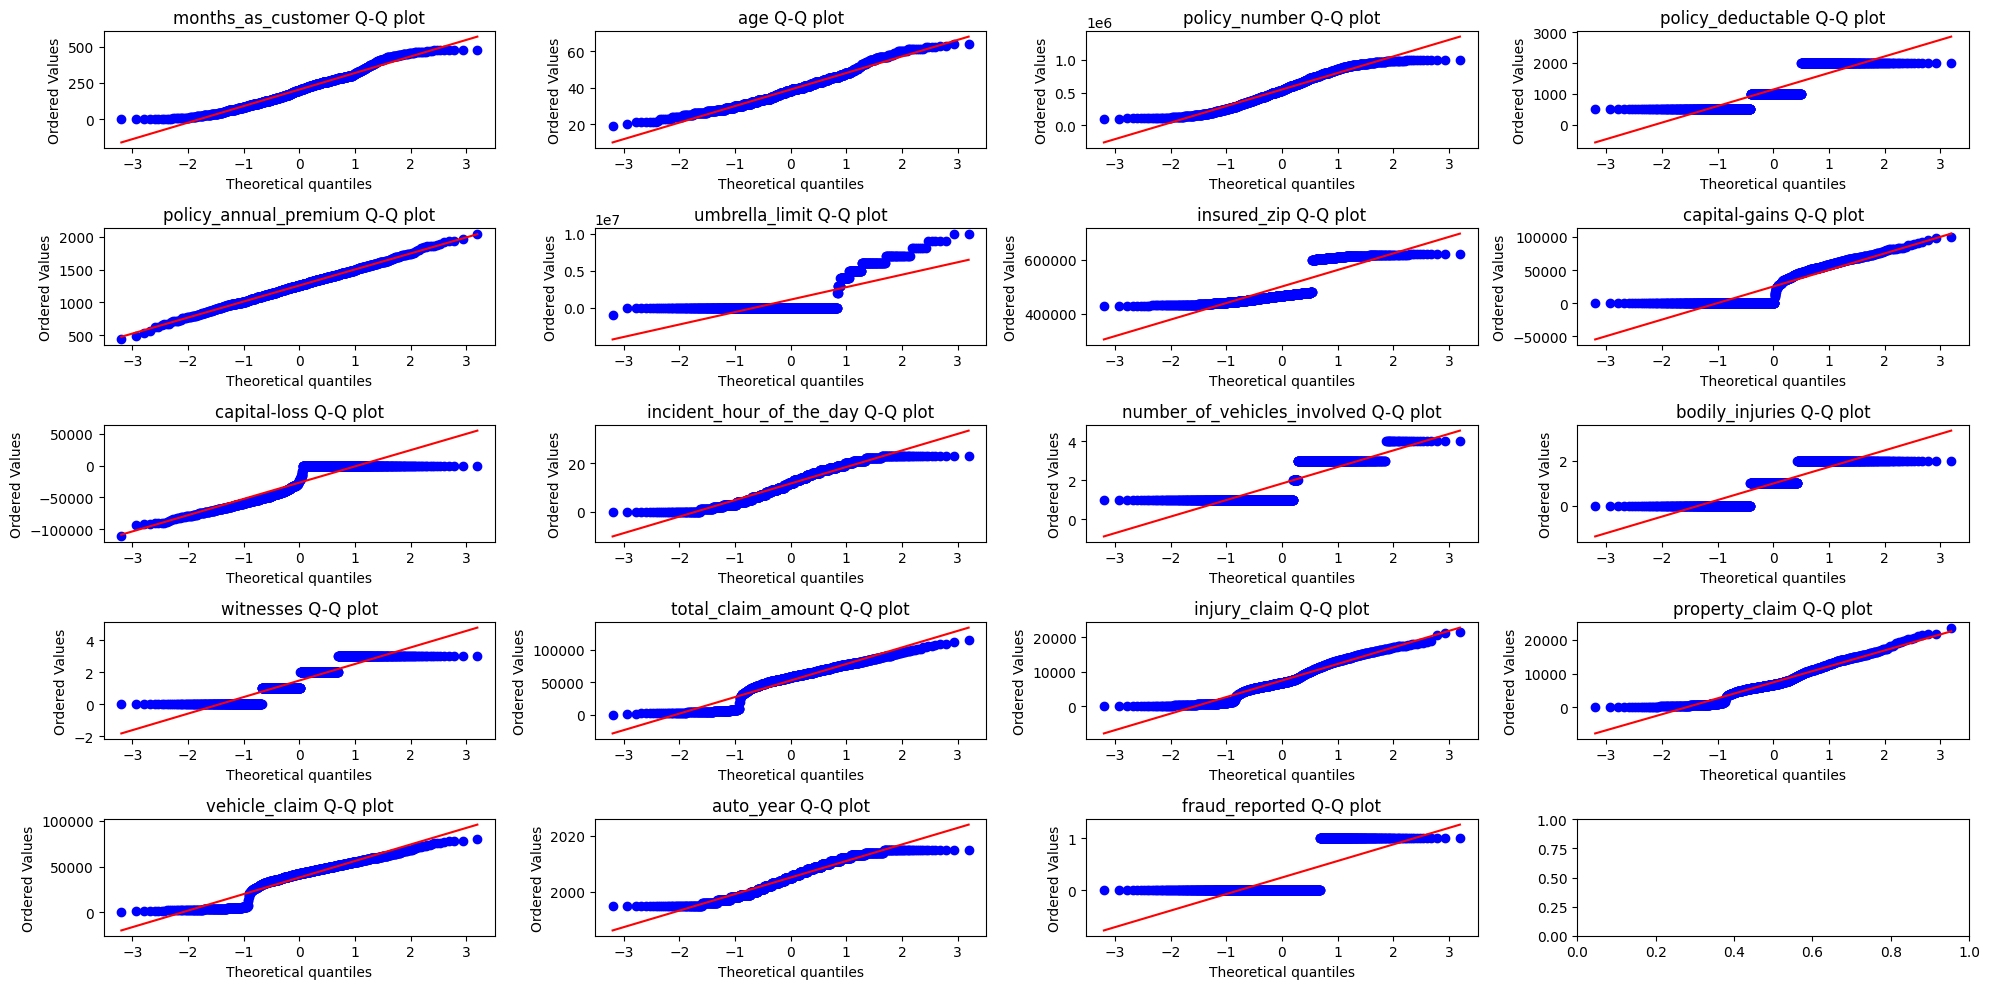

In [ ]:
import scipy.stats as stats

fig, axes = plt.subplots(5,4,figsize=(20,10))
axes = axes.flatten()
for i,col in enumerate(df_num.columns):
    stats.probplot(df_num[col], dist="norm", plot=axes[i])
    axes[i].set_title(col + ' Q-Q plot')

plt.tight_layout()
plt.show()

Seule policy annual premium suit la loie normale => application test de student  
autres variables = Test Mann whitneyu

In [46]:
#test student
from scipy.stats import ttest_ind

numerical_columns = ['policy_annual_premium']
for col in numerical_columns:
    group1 = df_num[df_num['fraud_reported']==0][col]
    group2 = df_num[df_num['fraud_reported']==1][col]
    stat, p = ttest_ind(group1, group2, nan_policy='omit')
    print(f'{col}: p-value = {p}')

policy_annual_premium: p-value = 0.6474289700892819


policy_annual_premium: PAS de difference de distribution significative entre fraude et non fraude

In [44]:
from scipy.stats import mannwhitneyu

for col in df_num.columns:
    group1 = df_num[df_num['fraud_reported']==0][col]
    group2 = df_num[df_num['fraud_reported']==1][col]
    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p < 0.05:
        print(f'{col}: p-value={p:.3f}')

total_claim_amount: p-value=0.000
injury_claim: p-value=0.005
property_claim: p-value=0.000
vehicle_claim: p-value=0.000
fraud_reported: p-value=0.000


**IV) Resultat général: Variables à tenir en compte selon les différentes approches (I,II,III)**
-  total_claim_amount
- injury_claim
- property_claim
- vehicle_claim

- policy_annual_premium
- incident_hour_of_the_day
- number_of_vehicles_involved
- bodily_injuries
 
- witnesses  
- age


**VI) variables qui se corrèlent à supprimer : apporte des infos redondantes**

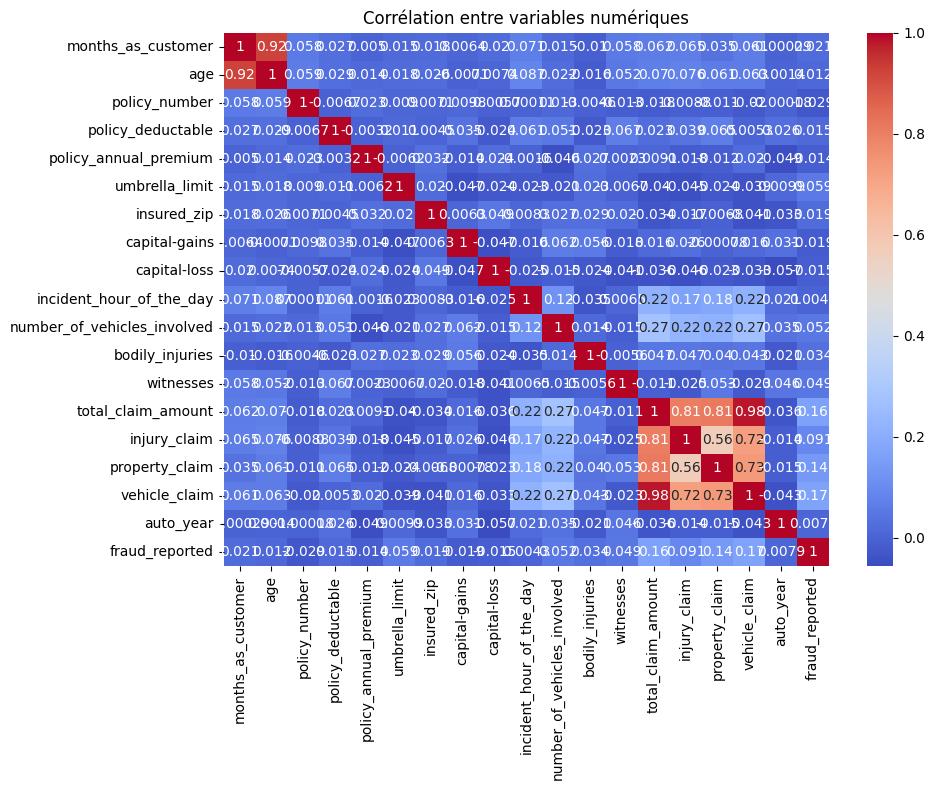

In [38]:
import seaborn as sns
correlation = df_num.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot = True,cbar = True, cmap = 'coolwarm')
plt.title("Corrélation entre variables numériques")
plt.tight_layout()
plt.show()

In [ ]:
-  1- total_claim_amount (injury_claim, property_claim,vehicle_claim)
- 2- policy_annual_premium
- incident_hour_of_the_day
- number_of_vehicles_involved
- bodily_injuries
 
- witnesses  
- age
